In [17]:
import torch
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

from visual_search import VisualSearchModel
from gist import Gist
from backbone import ConvGist
from dataset_handler import COCODatasetHandler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

coco = COCODatasetHandler("../CoCo", "train2017")
IMG_SIZE = 256
BACKBONE_WEIGHTS_PATH = "models/best_convgist_model.pth"

Using device: cuda
loading annotations into memory...
Done (t=7.38s)
creating index...
index created!


In [24]:
instances = coco.find_instances("person", 100, max_area=1200, min_area=1000)

In [25]:
gist_model = Gist(
    in_channels=1,
    stride=4,
    pooling=None,  # NO pooling to maintain 64x64 spatial resolution
    flatten=False
)
gist_model.eval()
gist_model.to(device)

for param in gist_model.parameters():
    param.requires_grad = False

# Get output shape
with torch.no_grad():
    dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)  # 1 channel for grayscale
    gist_features = gist_model(dummy_input)
    print(f"Gist features shape (unflattened): {gist_features.shape}")
    gist_channels = gist_features.shape[1]
    
    # Expected: (1, 49, 64, 64) or similar
    # With defaults: 4 scales x 6 orientations x 2 phases + 1 Gaussian = 49 channels

print(f"Gist output channels: {gist_channels}")
print(f"Spatial dimensions: {gist_features.shape[2]}x{gist_features.shape[3]}")

# Initialize ConvGist model with linear classifier
num_classes = 80
backbone = ConvGist(
    in_channels=gist_channels,
    n_classes=num_classes,
    classifier="linear"
)
backbone.to(device)

model = VisualSearchModel(gist_model, backbone, device=str(device), img_size=(IMG_SIZE, IMG_SIZE))

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

Gist features shape (unflattened): torch.Size([1, 97, 64, 64])
Gist output channels: 97
Spatial dimensions: 64x64


In [34]:
# Convert prototype list to PyTorch batch (directly from numpy, no PIL)
import torch.nn.functional as F

# Prepare batch data
instance = instances[79]

img = instance['image']

# Convert PIL to numpy if needed
if hasattr(img, 'convert'):  # PIL Image
    img = np.array(img.convert('L'))
bbox = instance['bbox_dict']

model.memorize_target(img, bbox)

  Fixations: 3
    Fixation 1: (119, 269) - Distance: 18.0px
    Fixation 2: (119, 269) - Distance: 18.0px
    Fixation 3: (119, 269) - Distance: 18.0px
  Final distance to target: 18.0 pixels


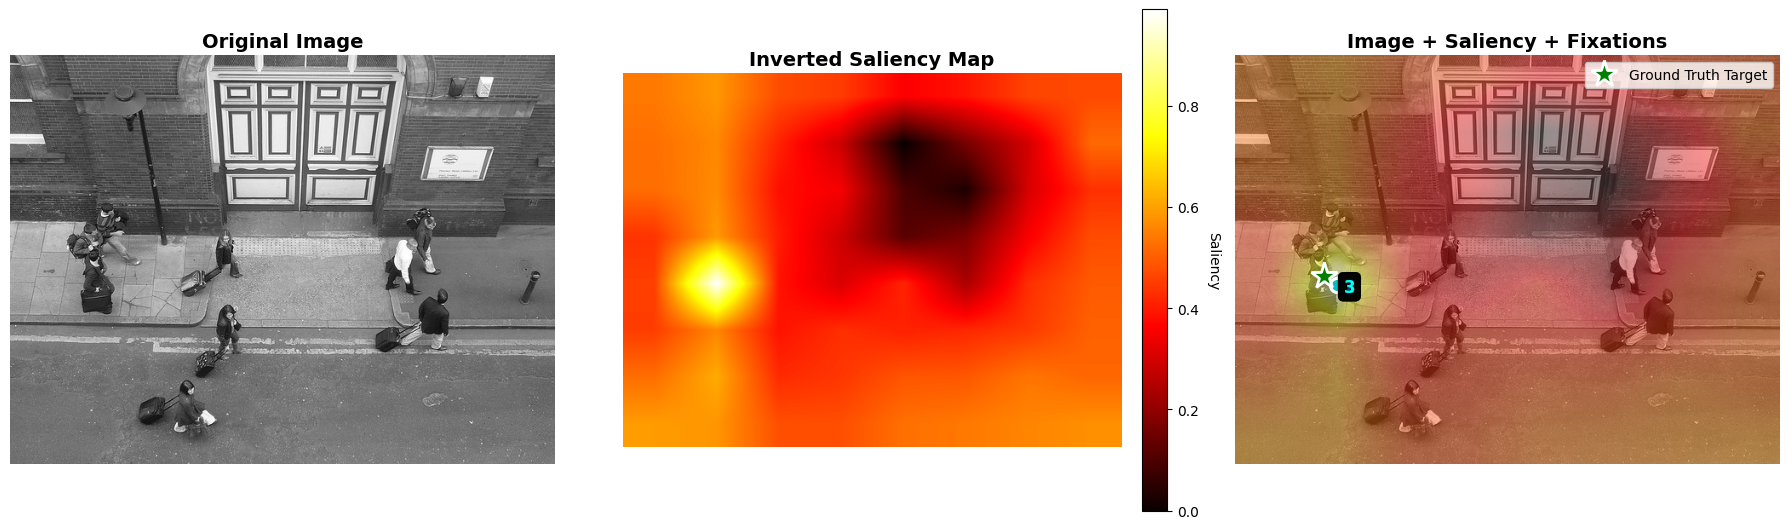

In [35]:
bbox = instance["bbox_dict"]
target_location = (int((bbox['x1'] + bbox['x2']) / 2), int((bbox['y1'] + bbox['y2']) / 2))

image = np.array(instance["image"])
saliency, saliency_upsampled, fixations = model.visual_search(image)

# Calculate performance metrics
final_fixation = fixations[-1]
distance_to_target = np.sqrt(
    (final_fixation[0] - target_location[0])**2 +
    (final_fixation[1] - target_location[1])**2
)

print(f"  Fixations: {len(fixations)}")
for i, (x, y) in enumerate(fixations):
    dist = np.sqrt((x - target_location[0])**2 + (y - target_location[1])**2)
    print(f"    Fixation {i+1}: ({x}, {y}) - Distance: {dist:.1f}px")

print(f"  Final distance to target: {distance_to_target:.1f} pixels")

# Visualize results
model.visualize_search(image, saliency_upsampled.squeeze(0), fixations, target_location)
# plt.figure()
# plt.imshow(saliency.detach().cpu().numpy().squeeze(0))
# plt.show()